In [1]:
# =========================
# TF2 Mixed PINN (Jupyter)
# =========================
import numpy as np
import time
import pickle
import scipy.io
import scipy.optimize
import matplotlib.pyplot as plt
#from pyDOE import lhs

import tensorflow as tf
tf.random.set_seed(1234)
np.random.seed(1234)


/opt/anaconda3/envs/tf2/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
import pickle

with open("pinn_cylinder_results.pkl", "rb") as f:
    results = pickle.load(f)

print(results.keys())


dict_keys(['loss_history', 'theta', 'p_pred', 'p_ref', 'meta'])


In [3]:
import numpy as np

def lhs(n_dim, n_samples, seed=None):
    """
    Latin Hypercube Sampling in [0,1]^n_dim.
    Returns array of shape (n_samples, n_dim).
    """
    rng = np.random.default_rng(seed)

    # Divide [0,1] into n_samples strata
    cut = np.linspace(0.0, 1.0, n_samples + 1)

    # Sample uniformly inside each stratum for each dimension
    u = rng.random((n_samples, n_dim))
    a = cut[:n_samples]
    b = cut[1:n_samples + 1]
    rdpoints = a[:, None] + (b - a)[:, None] * u  # (n_samples, n_dim)

    # Permute strata per dimension
    H = np.empty_like(rdpoints)
    for j in range(n_dim):
        order = rng.permutation(n_samples)
        H[:, j] = rdpoints[order, j]
    return H
# Helpers
# -------------------------
def DelCylPT(XY_c, xc=0.0, yc=0.0, r=0.1):
    """Delete points within cylinder."""
    dst = np.sqrt((XY_c[:,0]-xc)**2 + (XY_c[:,1]-yc)**2)
    return XY_c[dst > r, :]

def preprocess_mat(dir_path):
    """Load reference solution from Fenics or Fluent mat file.
       Expects keys: x,y,p,vx,vy"""
    data = scipy.io.loadmat(dir_path)
    X = data['x']; Y = data['y']
    P = data['p']
    vx = data['vx']; vy = data['vy']
    return (X.flatten()[:,None], Y.flatten()[:,None],
            vx.flatten()[:,None], vy.flatten()[:,None],
            P.flatten()[:,None])

def postProcess(xmin, xmax, ymin, ymax, field_ref, field_pinn, s=2, alpha=0.5, marker='o'):
    """Same plotting style as your original code."""
    x_ref, y_ref, u_ref, v_ref, p_ref = field_ref
    x_p, y_p, u_p, v_p, p_p = field_pinn

    fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(7, 4))
    fig.subplots_adjust(hspace=0.2, wspace=0.2)

    def _scatter(axh, x, y, c, title, vmin=None, vmax=None):
        cf = axh.scatter(x, y, c=c, alpha=alpha, edgecolors='none',
                         cmap='rainbow', marker=marker, s=int(s),
                         vmin=vmin, vmax=vmax)
        axh.axis('square')
        for key, spine in axh.spines.items():
            spine.set_visible(False)
        axh.set_xticks([]); axh.set_yticks([])
        axh.set_xlim([xmin, xmax]); axh.set_ylim([ymin, ymax])
        axh.set_title(title)
        fig.colorbar(cf, ax=axh, fraction=0.046, pad=0.04)

    _scatter(ax[0,0], x_p, y_p, u_p, r'$u$ (PINN)')
    _scatter(ax[1,0], x_p, y_p, v_p, r'$v$ (PINN)')
    _scatter(ax[2,0], x_p, y_p, p_p, r'$p$ (PINN)', vmin=-0.25, vmax=4.0)

    _scatter(ax[0,1], x_ref, y_ref, u_ref, r'$u$ (REF)')
    _scatter(ax[1,1], x_ref, y_ref, v_ref, r'$v$ (REF)')
    _scatter(ax[2,1], x_ref, y_ref, p_ref, r'$p$ (REF)', vmin=-0.25, vmax=4.0)

    plt.show()

# -------------------------
# Keras network
# -------------------------
class MLP(tf.keras.Model):
    def __init__(self, layers_sizes, activation="tanh"):
        super().__init__()
        self.hidden = []
        for w in layers_sizes[:-1]:
            self.hidden.append(tf.keras.layers.Dense(
                w, activation=activation,
                kernel_initializer="glorot_normal"
            ))
        self.out = tf.keras.layers.Dense(
            layers_sizes[-1], activation=None,
            kernel_initializer="glorot_normal"
        )

    def call(self, x, training=False):
        z = x
        for lyr in self.hidden:
            z = lyr(z)
        return self.out(z)

# -------------------------
# Mixed-form PINN in TF2
# -------------------------
class PINN_laminar_flow_TF2:
    """
    TF2 rewrite of your TF1 class:
    Outputs: psi, p, s11, s22, s12
    u = dpsi/dy
    v = -dpsi/dx
    """
    def __init__(self, Collo, INLET, OUTLET, WALL, uv_layers, lb, ub,
                 rho=1.0, mu=0.02, bc_weight=2.0):

        self.lb = lb.astype(np.float32).reshape(1,2)
        self.ub = ub.astype(np.float32).reshape(1,2)

        self.rho = tf.constant(rho, dtype=tf.float32)
        self.mu  = tf.constant(mu, dtype=tf.float32)
        self.bc_weight = tf.constant(bc_weight, dtype=tf.float32)

        # Data
        self.Collo = Collo.astype(np.float32)
        self.INLET = INLET.astype(np.float32)   # [x,y,u,v]
        self.OUTLET = OUTLET.astype(np.float32) # [x,y]
        self.WALL = WALL.astype(np.float32)     # [x,y]

        # Model
        hidden_widths = uv_layers[1:-1]
        out_dim = uv_layers[-1]  # 5
        self.net = MLP(hidden_widths + [out_dim], activation="tanh")

        self.loss_rec = []

    # --- forward outputs (psi,p,s11,s22,s12) ---
    def net_psips(self, x, y):
        xy = tf.concat([x, y], axis=1)
        out = self.net(xy)
        psi = out[:,0:1]
        p   = out[:,1:2]
        s11 = out[:,2:3]
        s22 = out[:,3:4]
        s12 = out[:,4:5]
        return psi, p, s11, s22, s12

    # --- compute u,v and first derivatives with a tape ---
    def uv_and_grads(self, x, y):
        with tf.GradientTape(persistent=True) as tape:
            tape.watch([x, y])
            psi, p, s11, s22, s12 = self.net_psips(x, y)
            u = tape.gradient(psi, y)
            v = -tape.gradient(psi, x)

        u_x = tape.gradient(u, x)
        u_y = tape.gradient(u, y)
        v_x = tape.gradient(v, x)
        v_y = tape.gradient(v, y)

        s11_x = tape.gradient(s11, x)
        s12_x = tape.gradient(s12, x)
        s12_y = tape.gradient(s12, y)
        s22_y = tape.gradient(s22, y)

        del tape
        return u, v, p, s11, s22, s12, u_x, u_y, v_x, v_y, s11_x, s12_x, s12_y, s22_y

    # --- PDE residuals (same as your net_f) ---
    def residuals(self, x, y):
        rho = self.rho
        mu  = self.mu

        (u, v, p, s11, s22, s12,
         u_x, u_y, v_x, v_y,
         s11_x, s12_x, s12_y, s22_y) = self.uv_and_grads(x, y)

        f_u = rho*(u*u_x + v*u_y) - s11_x - s12_y
        f_v = rho*(u*v_x + v*v_y) - s12_x - s22_y

        f_s11 = -p + 2.0*mu*u_x - s11
        f_s22 = -p + 2.0*mu*v_y - s22
        f_s12 = mu*(u_y + v_x) - s12

        f_p = p + 0.5*(s11 + s22)
        return f_u, f_v, f_s11, f_s22, f_s12, f_p

    # --- loss ---
    def loss_fn(self, Xc, WALL, INLET, OUTLET):
        # Collocation residuals
        xc = Xc[:,0:1]; yc = Xc[:,1:2]
        fu, fv, fs11, fs22, fs12, fp = self.residuals(xc, yc)
        loss_f = (tf.reduce_mean(tf.square(fu)) +
                  tf.reduce_mean(tf.square(fv)) +
                  tf.reduce_mean(tf.square(fs11)) +
                  tf.reduce_mean(tf.square(fs22)) +
                  tf.reduce_mean(tf.square(fs12)) +
                  tf.reduce_mean(tf.square(fp)))

        # WALL: u=v=0
        xw = WALL[:,0:1]; yw = WALL[:,1:2]
        u_w, v_w, *_ = self.uv_and_grads(xw, yw)
        loss_wall = tf.reduce_mean(tf.square(u_w)) + tf.reduce_mean(tf.square(v_w))

        # INLET: match prescribed u,v
        xi = INLET[:,0:1]; yi = INLET[:,1:2]
        ui = INLET[:,2:3]; vi = INLET[:,3:4]
        u_i, v_i, *_ = self.uv_and_grads(xi, yi)
        loss_in = tf.reduce_mean(tf.square(u_i - ui)) + tf.reduce_mean(tf.square(v_i - vi))

        # OUTLET: gauge pressure condition
        xo = OUTLET[:,0:1]; yo = OUTLET[:,1:2]
        _, p_o, _, _, _ = self.net_psips(xo, yo)

        # More stable than forcing p=0 pointwise:
        loss_out = tf.square(tf.reduce_mean(p_o))

        total = loss_f + self.bc_weight*(loss_wall + loss_in + loss_out)
        return total, loss_f, loss_wall, loss_in, loss_out

    # --- Adam training loop ---
    def train_adam(self, iters=10000, lr=5e-4, print_every=10):
        opt = tf.keras.optimizers.Adam(learning_rate=lr)

        Xc = tf.convert_to_tensor(self.Collo, dtype=tf.float32)
        WALL = tf.convert_to_tensor(self.WALL, dtype=tf.float32)
        INLET = tf.convert_to_tensor(self.INLET, dtype=tf.float32)
        OUTLET = tf.convert_to_tensor(self.OUTLET, dtype=tf.float32)

        for it in range(iters):
            with tf.GradientTape() as tape:
                loss, lf, lw, lin, lout = self.loss_fn(Xc, WALL, INLET, OUTLET)
            grads = tape.gradient(loss, self.net.trainable_variables)
            opt.apply_gradients(zip(grads, self.net.trainable_variables))

            if it % print_every == 0:
                print(f"It {it:6d} | loss={loss.numpy():.3e} "
                      f"| f={lf.numpy():.3e} wall={lw.numpy():.3e} "
                      f"in={lin.numpy():.3e} out={lout.numpy():.3e}")
            self.loss_rec.append(float(loss.numpy()))

    # --- L-BFGS with SciPy ---
    def train_lbfgs(self, maxiter=50000, maxcor=50):
        Xc = tf.convert_to_tensor(self.Collo, dtype=tf.float32)
        WALL = tf.convert_to_tensor(self.WALL, dtype=tf.float32)
        INLET = tf.convert_to_tensor(self.INLET, dtype=tf.float32)
        OUTLET = tf.convert_to_tensor(self.OUTLET, dtype=tf.float32)

        # pack/unpack weights
        def pack():
            return np.concatenate([v.numpy().reshape(-1) for v in self.net.trainable_variables]).astype(np.float64)

        def unpack(flat):
            idx = 0
            for v in self.net.trainable_variables:
                shape = v.shape
                size = int(np.prod(shape))
                v.assign(flat[idx:idx+size].reshape(shape).astype(np.float32))
                idx += size

        def loss_and_grad(flat):
            unpack(flat)
            with tf.GradientTape() as tape:
                loss, *_ = self.loss_fn(Xc, WALL, INLET, OUTLET)
            grads = tape.gradient(loss, self.net.trainable_variables)
            grad_flat = np.concatenate([g.numpy().reshape(-1) for g in grads]).astype(np.float64)
            return float(loss.numpy()), grad_flat

        x0 = pack()

        def callback(xk):
            l, _ = loss_and_grad(xk)
            self.loss_rec.append(l)
            print("L-BFGS loss:", l)

        res = scipy.optimize.minimize(
            fun=lambda w: loss_and_grad(w),
            x0=x0,
            jac=True,
            method="L-BFGS-B",
            callback=callback,
            options={"maxiter": maxiter, "maxcor": maxcor, "ftol": np.finfo(float).eps}
        )
        unpack(res.x)
        return res

    # --- Save/Load (TF2 style) ---
    def save(self, path="uvNN_tf2"):
        self.net.save_weights(path)

    def load(self, path="uvNN_tf2"):
        # build once
        dummy = tf.zeros((1,2), dtype=tf.float32)
        _ = self.net(dummy)
        self.net.load_weights(path)

    # --- predict u,v,p (and optionally stress) ---

    def predict(self, x_star, y_star):
        x = tf.convert_to_tensor(x_star.astype(np.float32))
        y = tf.convert_to_tensor(y_star.astype(np.float32))
    
        with tf.GradientTape(persistent=True) as tape:
            tape.watch([x, y])
            psi, p, _, _, _ = self.net_psips(x, y)
    
        u = tape.gradient(psi, y)
        v = -tape.gradient(psi, x)
        del tape
    
        return u.numpy(), v.numpy(), p.numpy()

    def predict_all(self, x_star, y_star):
        x = tf.convert_to_tensor(x_star.astype(np.float32))
        y = tf.convert_to_tensor(y_star.astype(np.float32))
    
        with tf.GradientTape(persistent=True) as tape:
            tape.watch([x, y])
            psi, p, s11, s22, s12 = self.net_psips(x, y)
    
        u = tape.gradient(psi, y)
        v = -tape.gradient(psi, x)
        del tape
    
        return u.numpy(), v.numpy(), p.numpy(), s11.numpy(), s22.numpy(), s12.numpy()


Collo shape: (49094, 2)


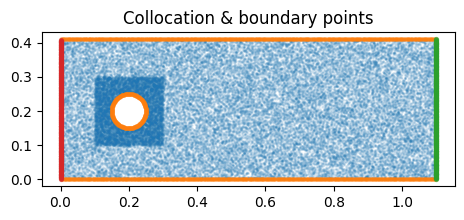

In [4]:

# =========================
# Main (same as your TF1)
# =========================

# Domain bounds
lb = np.array([0.0, 0.0])
ub = np.array([1.1, 0.41])

# Network configuration
uv_layers = [2] + 8*[40] + [5]

# ---- Boundary points (fixed to avoid list/array mixing issues) ----
L, H = 1.1, 0.41

# WALL (top/bottom)
Nw = 441
wall_up = np.hstack([L*lhs(1, Nw), H*np.ones((Nw,1))])
wall_lw = np.hstack([L*lhs(1, Nw), 0.0*np.ones((Nw,1))])

# INLET (x=0, parabolic)
U_max = 1.0
Ni = 201
y_in = H*lhs(1, Ni)
x_in = np.zeros((Ni,1))
u_in = 4*U_max*y_in*(H-y_in)/(H**2)
v_in = np.zeros_like(u_in)
INLET = np.hstack([x_in, y_in, u_in, v_in])

# OUTLET (x=L)
No = 201
OUTLET = np.hstack([L*np.ones((No,1)), H*lhs(1, No)])

# Cylinder boundary
r = 0.05
Nc = 251
theta = 2*np.pi*lhs(1, Nc)
CYLD = np.hstack([0.2 + r*np.cos(theta), 0.2 + r*np.sin(theta)])

WALL = np.vstack([CYLD, wall_up, wall_lw])

# ---- Collocation points ----
XY_c = lb + (ub - lb) * lhs(2, 40000)
XY_c_refine = np.array([0.1, 0.1]) + np.array([0.2, 0.2]) * lhs(2, 10000)
XY_c = np.vstack([XY_c, XY_c_refine])
XY_c = DelCylPT(XY_c, xc=0.2, yc=0.2, r=0.05)

# include boundary points in collocation set
XY_c = np.vstack([XY_c, WALL, CYLD, OUTLET, INLET[:,0:2]])
print("Collo shape:", XY_c.shape)

# Visualize points
fig, ax = plt.subplots(figsize=(6,2))
ax.set_aspect('equal')
plt.scatter(XY_c[:,0], XY_c[:,1], s=1, alpha=0.1)
plt.scatter(WALL[:,0], WALL[:,1], s=5, alpha=0.4)
plt.scatter(OUTLET[:,0], OUTLET[:,1], s=8, alpha=0.6)
plt.scatter(INLET[:,0], INLET[:,1], s=8, alpha=0.6)
plt.title("Collocation & boundary points")
plt.show()


In [5]:
# rebuild model (same settings as training!)
model = PINN_laminar_flow_TF2(
    XY_c, INLET, OUTLET, WALL,
    uv_layers, lb, ub,
    rho=1.0, mu=0.02, bc_weight=2.0
)

# load weights
model.load("uvNN_tf2_weights_4th.weights.h5")
print("✅ Weights loaded")

2026-02-21 20:40:02.408869: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-02-21 20:40:02.408901: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-02-21 20:40:02.408909: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-02-21 20:40:02.408946: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-21 20:40:02.408955: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


✅ Weights loaded


In [17]:
res2 = model.train_lbfgs(maxiter=20)

L-BFGS loss: 0.0002005968999583274
L-BFGS loss: 0.00020058805239386857
L-BFGS loss: 0.00020055293862242252
L-BFGS loss: 0.00020053854677826166
L-BFGS loss: 0.00020051162573508918
L-BFGS loss: 0.00020050116290804
L-BFGS loss: 0.00020048953592777252
L-BFGS loss: 0.00020047805446665734
L-BFGS loss: 0.00020046903227921575
L-BFGS loss: 0.00020045381097588688
L-BFGS loss: 0.0002004464331548661
L-BFGS loss: 0.00020043461699970067
L-BFGS loss: 0.0002004265843424946
L-BFGS loss: 0.00020041645620949566
L-BFGS loss: 0.000200399590539746
L-BFGS loss: 0.0002003951376536861
L-BFGS loss: 0.00020038113871123642
L-BFGS loss: 0.00020037511421833187
L-BFGS loss: 0.0002003660483751446
L-BFGS loss: 0.00020035292254760861


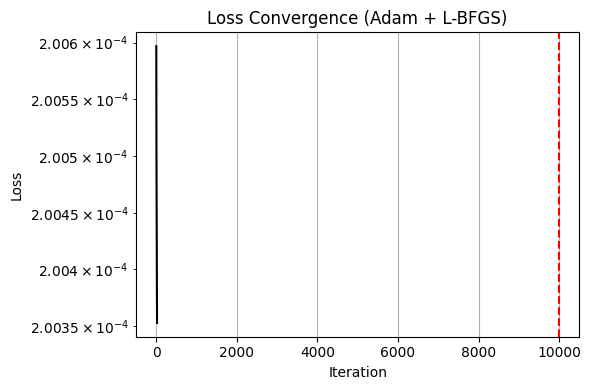

In [18]:
import matplotlib.pyplot as plt
import numpy as np

loss_load = np.array(model.loss_rec)
adam_iters = 10000  # number of Adam iterations

plt.figure(figsize=(6,4))
plt.semilogy(loss_load, 'k-', label="Total loss")
plt.axvline(adam_iters, color='r', ls='--', lw=1.5, label="Adam → L-BFGS")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss Convergence (Adam + L-BFGS)")
plt.grid(True)
plt.tight_layout()
plt.show()


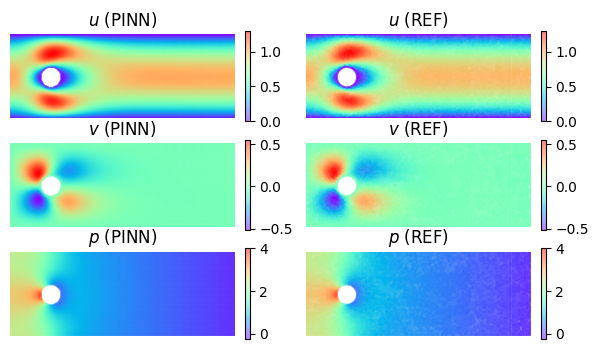

In [6]:
# ---- Compare with reference (optional) ----
# Change this path to your mat file:
x_ref, y_ref, u_ref, v_ref, p_ref = preprocess_mat("FluentSol.mat")
field_ref = [x_ref, y_ref, u_ref, v_ref, p_ref]

# PINN prediction grid
xg = np.linspace(0, L, 251)
yg = np.linspace(0, H, 101)
Xg, Yg = np.meshgrid(xg, yg)
x_star = Xg.flatten()[:,None]
y_star = Yg.flatten()[:,None]
dst = np.sqrt((x_star-0.2)**2 + (y_star-0.2)**2)
mask = dst[:,0] >= r
x_star = x_star[mask]
y_star = y_star[mask]

u_p, v_p, p_p = model.predict(x_star, y_star)

field_pinn = [x_star, y_star, u_p, v_p, p_p]

# If you have field_ref, uncomment:
postProcess(0, L, 0, H, field_ref, field_pinn, s=3, alpha=0.5)


Relative L2 error on line: 0.026006361364922837


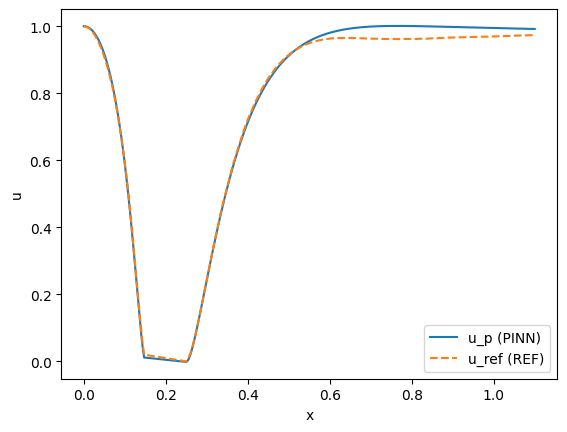

In [7]:
y0 = 0.205
x_line = np.linspace(0.0, 1.1, 300)[:, None]
y_line = y0 * np.ones_like(x_line)

# remove cylinder interior
r = 0.05
dst = np.sqrt((x_line-0.2)**2 + (y_line-0.2)**2)
mask = (dst[:,0] >= r)
x_line_m = x_line[mask]
y_line_m = y_line[mask]

# PINN prediction
u_p, v_p, p_p = model.predict(x_line_m, y_line_m)

# REF interpolation onto same line points
from scipy.interpolate import griddata
u_ref_line = griddata(
    points=np.hstack([x_ref, y_ref]),
    values=u_ref.reshape(-1),
    xi=np.hstack([x_line_m, y_line_m]),
    method="linear"
)

# error metrics on that line
err = u_p.reshape(-1) - u_ref_line.reshape(-1)
L2_rel = np.linalg.norm(err) / (np.linalg.norm(u_ref_line) + 1e-12)
print("Relative L2 error on line:", L2_rel)

# plot comparison
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x_line_m, u_p, label="u_p (PINN)")
plt.plot(x_line_m, u_ref_line, "--", label="u_ref (REF)")
plt.legend(); plt.xlabel("x"); plt.ylabel("u"); plt.show()


Relative L2 error on line: 0.2344307346109838


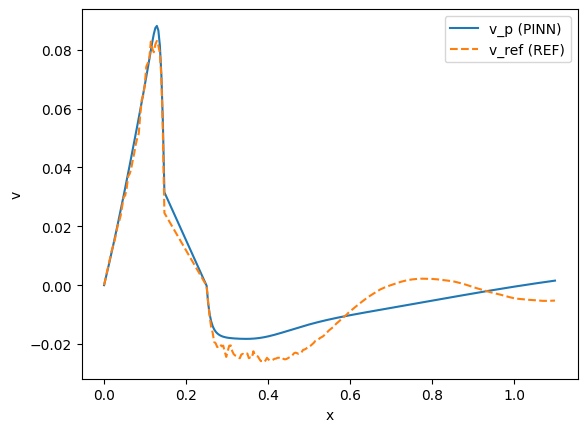

In [8]:
y0 = 0.205
x_line = np.linspace(0.0, 1.1, 300)[:, None]
y_line = y0 * np.ones_like(x_line)

# remove cylinder interior
r = 0.05
dst = np.sqrt((x_line-0.2)**2 + (y_line-0.2)**2)
mask = (dst[:,0] >= r)
x_line_m = x_line[mask]
y_line_m = y_line[mask]

# PINN prediction
u_p, v_p, p_p = model.predict(x_line_m, y_line_m)

# REF interpolation onto same line points
from scipy.interpolate import griddata
v_ref_line = griddata(
    points=np.hstack([x_ref, y_ref]),
    values=v_ref.reshape(-1),
    xi=np.hstack([x_line_m, y_line_m]),
    method="linear"
)

# error metrics on that line
err = v_p.reshape(-1) - v_ref_line.reshape(-1)
L2_rel = np.linalg.norm(err) / (np.linalg.norm(v_ref_line) + 1e-12)
print("Relative L2 error on line:", L2_rel)

# plot comparison
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x_line_m, v_p, label="v_p (PINN)")
plt.plot(x_line_m, v_ref_line, "--", label="v_ref (REF)")
plt.legend(); plt.xlabel("x"); plt.ylabel("v"); plt.show()


Relative L2 error on line: 0.027579887687027776


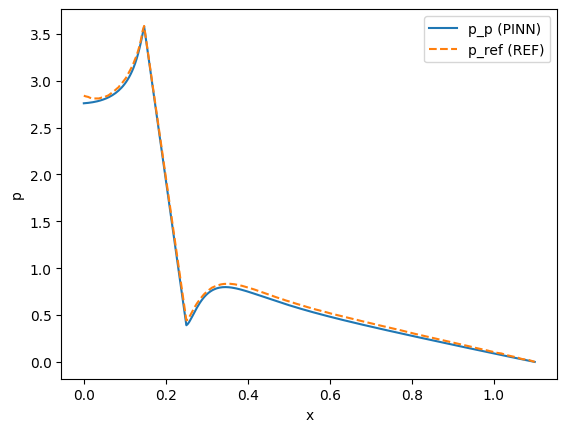

In [9]:
y0 = 0.205
x_line = np.linspace(0.0, 1.1, 300)[:, None]
y_line = y0 * np.ones_like(x_line)

# remove cylinder interior
r = 0.05
dst = np.sqrt((x_line-0.2)**2 + (y_line-0.2)**2)
mask = (dst[:,0] >= r)
x_line_m = x_line[mask]
y_line_m = y_line[mask]

# PINN prediction
u_p, v_p, p_p = model.predict(x_line_m, y_line_m)

# REF interpolation onto same line points
from scipy.interpolate import griddata
p_ref_line = griddata(
    points=np.hstack([x_ref, y_ref]),
    values=p_ref.reshape(-1),
    xi=np.hstack([x_line_m, y_line_m]),
    method="linear"
)

# error metrics on that line
err = p_p.reshape(-1) - p_ref_line.reshape(-1)
L2_rel = np.linalg.norm(err) / (np.linalg.norm(p_ref_line) + 1e-12)
print("Relative L2 error on line:", L2_rel)

# plot comparison
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x_line_m, p_p, label="p_p (PINN)")
plt.plot(x_line_m, p_ref_line, "--", label="p_ref (REF)")
plt.legend(); plt.xlabel("x"); plt.ylabel("p"); plt.show()


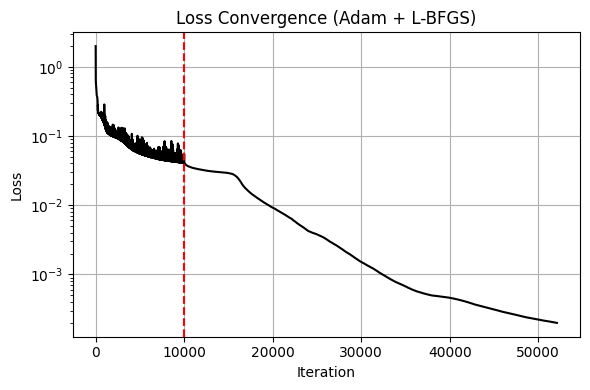

In [10]:
import matplotlib.pyplot as plt
import numpy as np

loss = np.array(results['loss_history'])
adam_iters = 10000  # number of Adam iterations

plt.figure(figsize=(6,4))
plt.semilogy(loss, 'k-', label="Total loss")
plt.axvline(adam_iters, color='r', ls='--', lw=1.5, label="Adam → L-BFGS")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss Convergence (Adam + L-BFGS)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
def compute_drag_lift_cylinder(model, xc=0.2, yc=0.2, r=0.05, N=4000):
    """
    D = ∮ (sigma n)_x dS
    L = ∮ (sigma n)_y dS
    with sigma = [[s11, s12],[s12, s22]] predicted by the mixed PINN.

    Returns: D, L (per unit thickness in 2D)
    """
    theta = np.linspace(0.0, 2*np.pi, N, endpoint=False).reshape(-1, 1)
    x = xc + r*np.cos(theta)
    y = yc + r*np.sin(theta)

    # outward normal on circle
    nx = np.cos(theta)
    ny = np.sin(theta)

    # get stresses from model (your predict_all)
    u, v, p, s11, s22, s12 = model.predict_all(x, y)

    # traction t = sigma n
    tx = s11*nx + s12*ny
    ty = s12*nx + s22*ny

    # line integral on circle: dS = r dtheta
    dtheta = 2*np.pi / N
    D = float(np.sum(tx) * r * dtheta)
    L = float(np.sum(ty) * r * dtheta)
    return D, L


In [13]:
D, L = compute_drag_lift_cylinder(model, xc=0.2, yc=0.2, r=0.05, N=4000)
print("Drag D =", D)
print("Lift L =", L)

Drag D = 0.4407184168087708
Lift L = 0.010780443418443544
